In [1]:
# Cell 1 — Imports
import os
import json
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from dotenv import load_dotenv

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

load_dotenv()

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

print("✅ Imports loaded")

✅ Imports loaded


In [2]:
# Cell 2 — Create Spark Session
spark = SparkSession.builder \
    .appName("Project2-EDA") \
    .master("local[*]") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.driver.memory", "4g") \
    .config(
        "spark.sql.parquet.int96RebaseMode",
        "LEGACY") \
    .config(
        "spark.sql.parquet.datetimeRebaseMode",
        "LEGACY") \
    .config(
        "spark.sql.parquet.enableVectorizedReader",
        "false") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

# Load data — read each file & standardize schema
import glob
from pyspark.sql.types import (
    StructType, StructField,
    StringType, LongType,
    DoubleType, TimestampType
)

schema = StructType([
    StructField("VendorID", LongType(), True),
    StructField("tpep_pickup_datetime", TimestampType(), True),
    StructField("tpep_dropoff_datetime", TimestampType(), True),
    StructField("passenger_count", LongType(), True),
    StructField("trip_distance", DoubleType(), True),
    StructField("RatecodeID", LongType(), True),
    StructField("store_and_fwd_flag", StringType(), True),
    StructField("PULocationID", LongType(), True),
    StructField("DOLocationID", LongType(), True),
    StructField("payment_type", LongType(), True),
    StructField("fare_amount", DoubleType(), True),
    StructField("extra", DoubleType(), True),
    StructField("mta_tax", DoubleType(), True),
    StructField("tip_amount", DoubleType(), True),
    StructField("tolls_amount", DoubleType(), True),
    StructField("improvement_surcharge", DoubleType(), True),
    StructField("total_amount", DoubleType(), True),
    StructField("congestion_surcharge", DoubleType(), True),
    StructField("airport_fee", DoubleType(), True),
])

# Read each parquet file and cast to target schema
raw_dir = "../data/raw"
parquet_files = sorted(glob.glob(f"{raw_dir}/*.parquet"))

dfs = []
for pq_file in parquet_files:
    temp_df = spark.read.parquet(pq_file)
    # Cast columns to target types
    for field in schema.fields:
        if field.name.lower() in [c.lower() for c in temp_df.columns]:
            col_actual = next(
                c for c in temp_df.columns 
                if c.lower() == field.name.lower()
            )
            temp_df = temp_df.withColumn(
                field.name,
                F.col(col_actual).cast(field.dataType)
            )
    temp_df = temp_df.select([f.name for f in schema.fields])
    dfs.append(temp_df)

df = dfs[0]
for temp_df in dfs[1:]:
    df = df.unionByName(temp_df, allowMissingColumns=True)

total_rows = df.count()

print(f"✅ Spark ready")
print(f"   Records: {total_rows:,}")
print(f"   Cores:   "
      f"{spark.sparkContext.defaultParallelism}")

✅ Spark ready
   Records: 9,384,487
   Cores:   8


**Create Hourly Aggregations**

This is the core transformation — converting individual trip records into hourly trip counts which becomes our forecasting target.

In [3]:
# Cell 3 — Create hourly trip counts
print("Creating hourly aggregations...")

# Extract time components and aggregate
hourly_df = df.withColumn(
    'pickup_hour',
    F.date_trunc('hour',
                 'tpep_pickup_datetime')
).groupBy('pickup_hour') \
 .agg(
    F.count('*').alias('trip_count'),
    F.avg('fare_amount').alias('avg_fare'),
    F.avg('trip_distance').alias(
        'avg_distance'),
    F.avg('passenger_count').alias(
        'avg_passengers'),
    F.sum('total_amount').alias(
        'total_revenue'),
    F.avg('tip_amount').alias('avg_tip'),
    F.stddev('fare_amount').alias(
        'fare_stddev')
).orderBy('pickup_hour')

# Convert to pandas for visualization
# (aggregated data is small enough for pandas)
hourly_pdf = hourly_df.toPandas()
hourly_pdf['pickup_hour'] = pd.to_datetime(
    hourly_pdf['pickup_hour'])
hourly_pdf = hourly_pdf.sort_values(
    'pickup_hour').reset_index(drop=True)

print(f"✅ Hourly aggregation complete")
print(f"   Hours in dataset: {len(hourly_pdf):,}")
print(f"   Date range: "
      f"{hourly_pdf['pickup_hour'].min()} to "
      f"{hourly_pdf['pickup_hour'].max()}")
print(f"\nSample:")
print(hourly_pdf.head(5))

Creating hourly aggregations...
✅ Hourly aggregation complete
   Hours in dataset: 2,212
   Date range: 2001-01-01 00:00:00 to 2023-04-05 20:00:00

Sample:
          pickup_hour  trip_count   avg_fare  avg_distance  avg_passengers  \
0 2001-01-01 00:00:00           2  52.950000     12.545000        1.500000   
1 2001-01-01 15:00:00           1  38.000000      9.130000        2.000000   
2 2002-12-31 23:00:00           2  50.850000     12.250000        1.000000   
3 2003-01-01 00:00:00           3  64.133333     12.723333        1.666667   
4 2008-12-31 10:00:00           1  17.000000      3.010000        1.000000   

   total_revenue  avg_tip  fare_stddev  
0         128.70      3.5    24.112341  
1          43.00      0.0          NaN  
2         117.25      0.0    27.082190  
3         209.45      0.0    82.861591  
4          21.00      0.0          NaN  


**Trip Count Time Series Plot**

In [ ]:
# Cell 4 — Overall time series
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Full time series
axes[0].plot(
    hourly_pdf['pickup_hour'],
    hourly_pdf['trip_count'],
    color='#2196F3', linewidth=0.8,
    alpha=0.7)
axes[0].set_title(
    'NYC Taxi Hourly Trip Count — Full Dataset',
    fontsize=13, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Trips per Hour')
axes[0].xaxis.set_major_formatter(
    mdates.DateFormatter('%Y-%m-%d'))
axes[0].xaxis.set_major_locator(
    mdates.WeekdayLocator(interval=2))
plt.setp(axes[0].xaxis.get_majorticklabels(),
         rotation=45)

# One week zoom
one_week = hourly_pdf[
    (hourly_pdf['pickup_hour'] >=
     '2023-01-09') &
    (hourly_pdf['pickup_hour'] <
     '2023-01-16')
]
axes[1].plot(
    one_week['pickup_hour'],
    one_week['trip_count'],
    color='#F44336', linewidth=2,
    marker='o', markersize=3)
axes[1].set_title(
    'One Week Zoom (Jan 9-15, 2023) — '
    'Daily Patterns Visible',
    fontsize=13, fontweight='bold')
axes[1].set_xlabel('Date and Hour')
axes[1].set_ylabel('Trips per Hour')
axes[1].xaxis.set_major_formatter(
    mdates.DateFormatter('%a %m/%d'))
axes[1].xaxis.set_major_locator(
    mdates.DayLocator())
plt.setp(axes[1].xaxis.get_majorticklabels(),
         rotation=45)

plt.tight_layout()
plt.savefig('../logs/trip_count_timeseries.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTrip count statistics:")
print(hourly_pdf['trip_count'].describe()\
      .round(2))

**Hourly Pattern Analysis**

Analyzing hourly patterns...


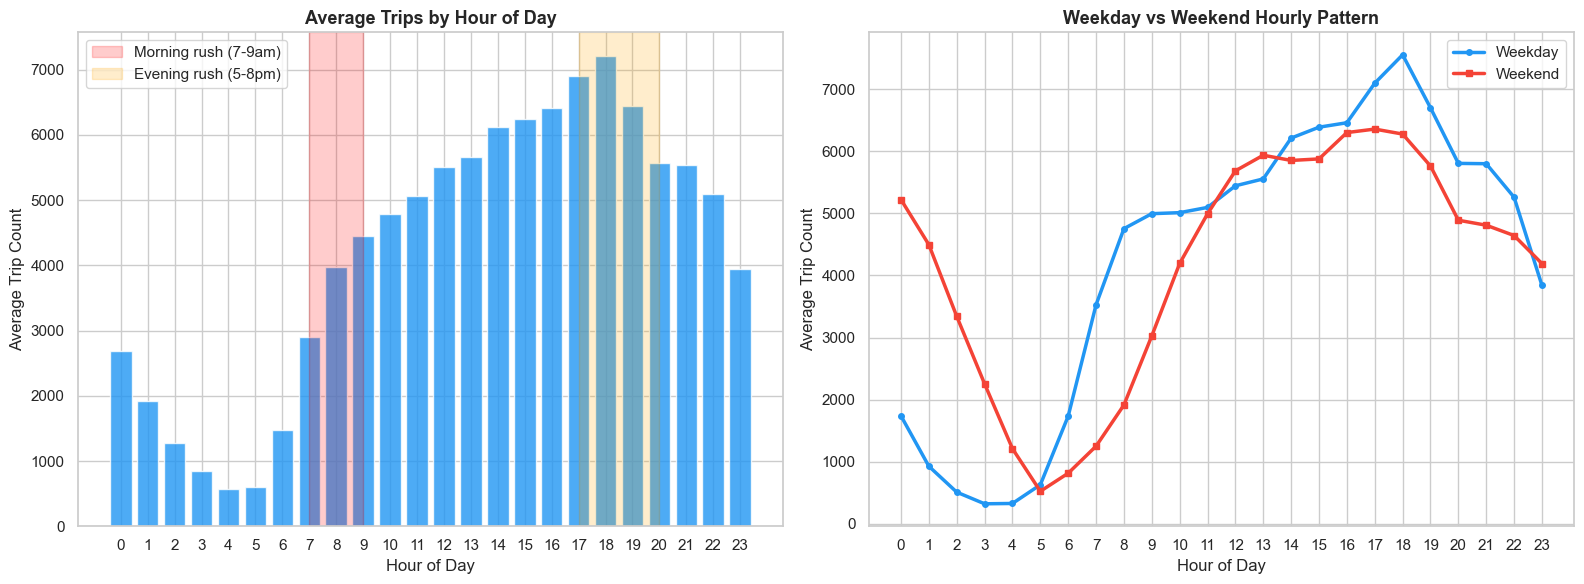


=== KEY HOURLY INSIGHTS ===
Peak hour:    18:00 (7211 avg trips)
Trough hour:  4:00 (573 avg trips)
Peak/trough ratio: 12.6x


In [ ]:
# Cell 5 — Average trips by hour of day
print("Analyzing hourly patterns...")

# Add time features to pandas df
hourly_pdf['hour_of_day'] = \
    hourly_pdf['pickup_hour'].dt.hour
hourly_pdf['day_of_week'] = \
    hourly_pdf['pickup_hour'].dt.dayofweek
hourly_pdf['day_name'] = \
    hourly_pdf['pickup_hour']\
    .dt.day_name()
hourly_pdf['is_weekend'] = \
    hourly_pdf['day_of_week'].isin([5, 6])
hourly_pdf['month'] = \
    hourly_pdf['pickup_hour'].dt.month

# Average by hour of day
avg_by_hour = hourly_pdf.groupby(
    'hour_of_day')['trip_count'].mean()

fig, axes = plt.subplots(1, 2,
                          figsize=(16, 6))

# Overall hourly pattern
axes[0].bar(avg_by_hour.index,
            avg_by_hour.values,
            color='#2196F3', alpha=0.8)
axes[0].axvspan(7, 9, alpha=0.2,
                color='red',
                label='Morning rush (7-9am)')
axes[0].axvspan(17, 20, alpha=0.2,
                color='orange',
                label='Evening rush (5-8pm)')
axes[0].set_title(
    'Average Trips by Hour of Day',
    fontsize=13, fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Average Trip Count')
axes[0].set_xticks(range(0, 24))
axes[0].legend()

# Weekday vs Weekend
weekday_hourly = hourly_pdf[
    ~hourly_pdf['is_weekend']
].groupby('hour_of_day')['trip_count'].mean()

weekend_hourly = hourly_pdf[
    hourly_pdf['is_weekend']
].groupby('hour_of_day')['trip_count'].mean()

axes[1].plot(weekday_hourly.index,
             weekday_hourly.values,
             color='#2196F3', linewidth=2.5,
             label='Weekday', marker='o',
             markersize=4)
axes[1].plot(weekend_hourly.index,
             weekend_hourly.values,
             color='#F44336', linewidth=2.5,
             label='Weekend', marker='s',
             markersize=4)
axes[1].set_title(
    'Weekday vs Weekend Hourly Pattern',
    fontsize=13, fontweight='bold')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Average Trip Count')
axes[1].set_xticks(range(0, 24))
axes[1].legend()

plt.tight_layout()
plt.savefig('../logs/hourly_patterns.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\n=== KEY HOURLY INSIGHTS ===")
print(f"Peak hour:    "
      f"{avg_by_hour.idxmax()}:00 "
      f"({avg_by_hour.max():.0f} avg trips)")
print(f"Trough hour:  "
      f"{avg_by_hour.idxmin()}:00 "
      f"({avg_by_hour.min():.0f} avg trips)")
print(f"Peak/trough ratio: "
      f"{avg_by_hour.max()/avg_by_hour.min():.1f}x")

**Day of Week Analysis**

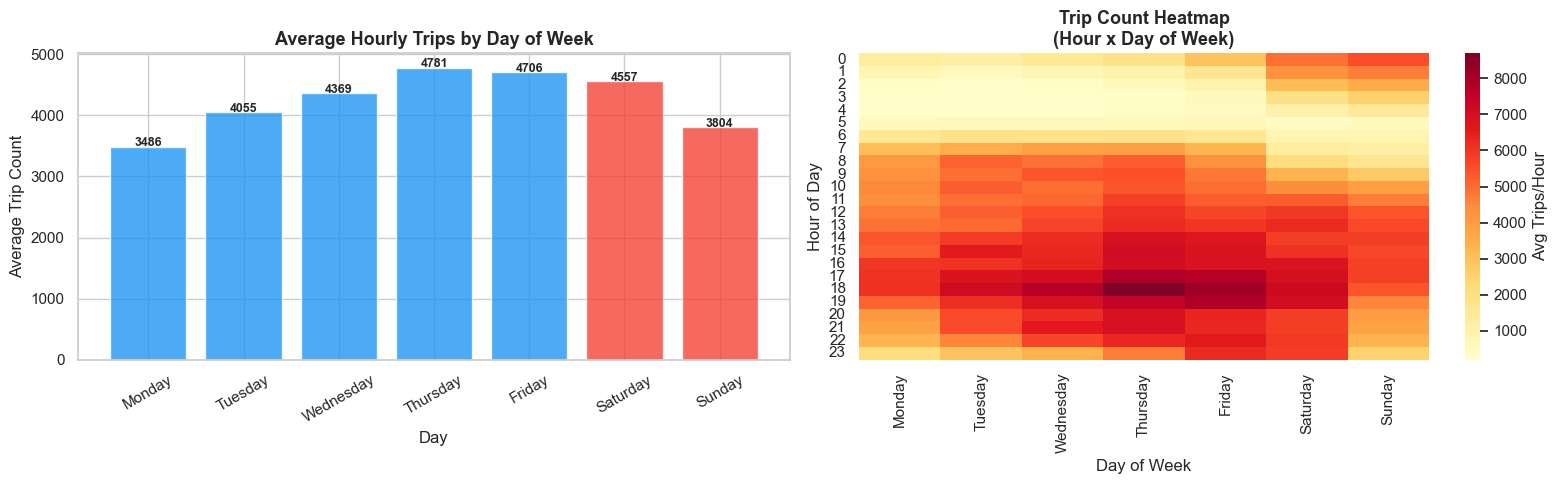


=== DAY OF WEEK INSIGHTS ===
Busiest day:  Thursday (4781 avg trips/hr)
Quietest day: Monday (3486 avg trips/hr)


In [ ]:
# Cell 6 — Day of week patterns
fig, axes = plt.subplots(1, 2,
                          figsize=(16, 5))

# Average by day of week
day_order = ['Monday', 'Tuesday',
             'Wednesday', 'Thursday',
             'Friday', 'Saturday', 'Sunday']
avg_by_day = hourly_pdf.groupby(
    'day_name')['trip_count']\
    .mean().reindex(day_order)

colors = ['#2196F3'] * 5 + \
         ['#F44336', '#F44336']
axes[0].bar(avg_by_day.index,
            avg_by_day.values,
            color=colors, alpha=0.8)
axes[0].set_title(
    'Average Hourly Trips by Day of Week',
    fontsize=13, fontweight='bold')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Average Trip Count')
plt.setp(axes[0].xaxis.get_majorticklabels(),
         rotation=30)
for bar, val in zip(axes[0].patches,
                    avg_by_day.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        f'{val:.0f}', ha='center',
        fontsize=9, fontweight='bold')

# Heatmap — hour x day
pivot = hourly_pdf.pivot_table(
    values='trip_count',
    index='hour_of_day',
    columns='day_name',
    aggfunc='mean'
)[day_order]

sns.heatmap(
    pivot, ax=axes[1],
    cmap='YlOrRd',
    fmt='.0f', annot=False,
    cbar_kws={'label': 'Avg Trips/Hour'})
axes[1].set_title(
    'Trip Count Heatmap\n(Hour x Day of Week)',
    fontsize=13, fontweight='bold')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Hour of Day')

plt.tight_layout()
plt.savefig('../logs/day_of_week_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\n=== DAY OF WEEK INSIGHTS ===")
print(f"Busiest day:  "
      f"{avg_by_day.idxmax()} "
      f"({avg_by_day.max():.0f} avg trips/hr)")
print(f"Quietest day: "
      f"{avg_by_day.idxmin()} "
      f"({avg_by_day.min():.0f} avg trips/hr)")

**Autocorrelation Analysis**

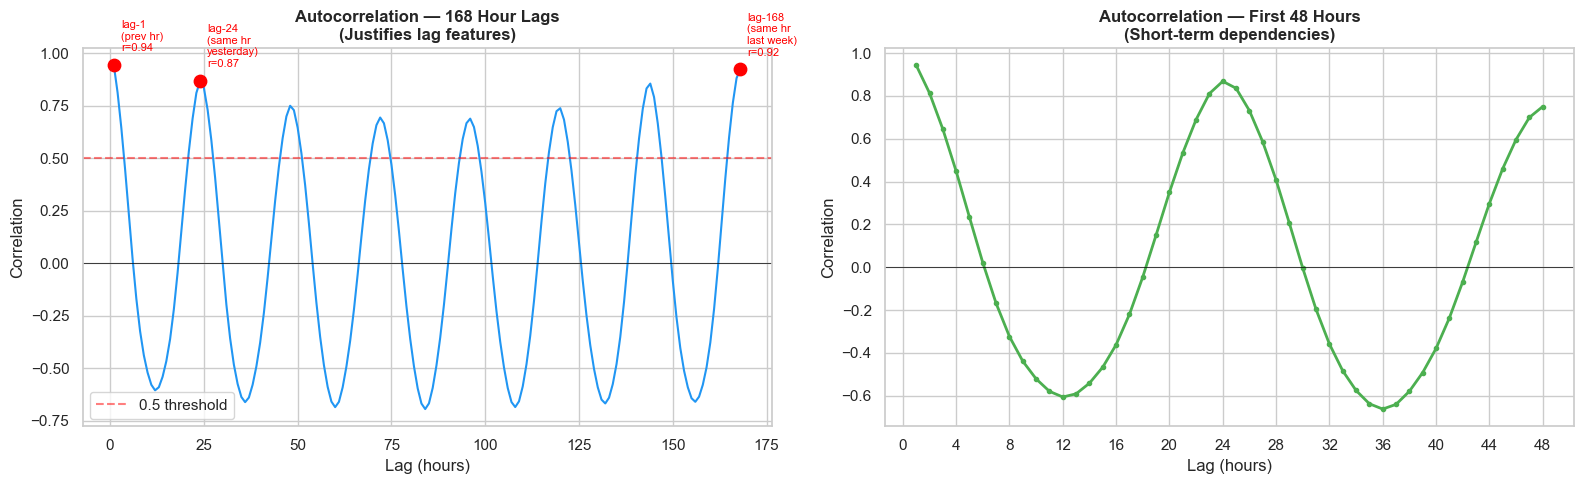


=== AUTOCORRELATION INSIGHTS ===
  Lag   1h: r=0.9433
  Lag   2h: r=0.8133
  Lag   3h: r=0.6447
  Lag   6h: r=0.0210
  Lag  12h: r=-0.6055
  Lag  24h: r=0.8680
  Lag  48h: r=0.7500
  Lag 168h: r=0.9228


In [ ]:
# Cell 7 — Autocorrelation
# Justifies lag features in Phase 4

from pandas.plotting import autocorrelation_plot

fig, axes = plt.subplots(1, 2,
                          figsize=(16, 5))

# Manual autocorrelation computation
trip_series = hourly_pdf['trip_count'].values
max_lag     = 168  # 1 week of hours

correlations = [
    np.corrcoef(
        trip_series[:-lag],
        trip_series[lag:]
    )[0, 1]
    for lag in range(1, max_lag + 1)
]

lags = range(1, max_lag + 1)

axes[0].plot(lags, correlations,
             color='#2196F3', linewidth=1.5)
axes[0].axhline(y=0, color='black',
                linestyle='-', linewidth=0.5)
axes[0].axhline(y=0.5, color='red',
                linestyle='--', alpha=0.5,
                label='0.5 threshold')

# Highlight key lags
for lag, label in [(1, 'lag-1\n(prev hr)'),
                   (24, 'lag-24\n(same hr\nyesterday)'),
                   (168, 'lag-168\n(same hr\nlast week)')]:
    corr = correlations[lag-1]
    axes[0].scatter([lag], [corr],
                    color='red', s=80,
                    zorder=5)
    axes[0].annotate(
        f'{label}\nr={corr:.2f}',
        (lag, corr),
        textcoords="offset points",
        xytext=(5, 10),
        fontsize=8, color='red')

axes[0].set_title(
    'Autocorrelation — 168 Hour Lags\n'
    '(Justifies lag features)',
    fontsize=12, fontweight='bold')
axes[0].set_xlabel('Lag (hours)')
axes[0].set_ylabel('Correlation')
axes[0].legend()

# Zoom into first 48 hours
axes[1].plot(lags[:48], correlations[:48],
             color='#4CAF50', linewidth=2,
             marker='o', markersize=3)
axes[1].axhline(y=0, color='black',
                linewidth=0.5)
axes[1].set_title(
    'Autocorrelation — First 48 Hours\n'
    '(Short-term dependencies)',
    fontsize=12, fontweight='bold')
axes[1].set_xlabel('Lag (hours)')
axes[1].set_ylabel('Correlation')
axes[1].set_xticks(range(0, 49, 4))

plt.tight_layout()
plt.savefig('../logs/autocorrelation.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\n=== AUTOCORRELATION INSIGHTS ===")
for lag in [1, 2, 3, 6, 12, 24, 48, 168]:
    corr = correlations[lag-1]
    print(f"  Lag {lag:>3}h: r={corr:.4f}")

**Distribution Analysis**

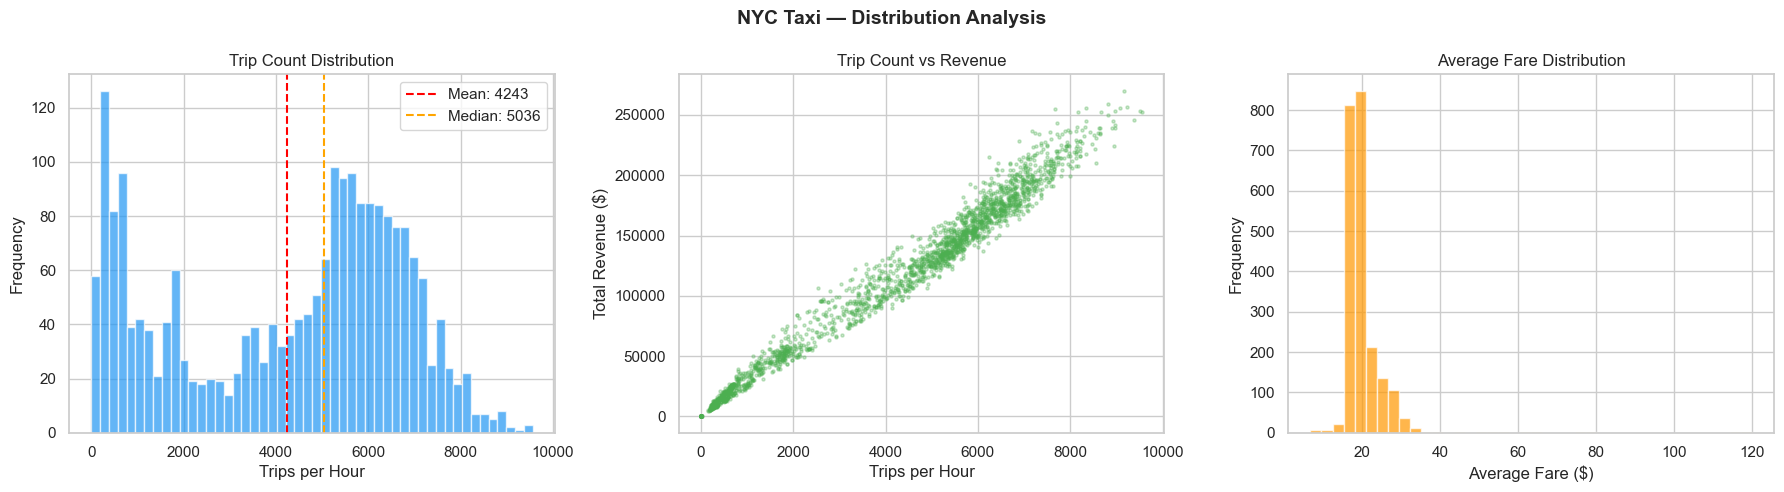


=== DISTRIBUTION STATS ===
Trip count mean:   4243
Trip count std:    2492
Trip count min:    1
Trip count max:    9562
Avg fare mean:     $19.92


In [ ]:
# Cell 8 — Trip count distribution
fig, axes = plt.subplots(1, 3,
                          figsize=(18, 5))

# Histogram of trip counts
axes[0].hist(
    hourly_pdf['trip_count'],
    bins=50, color='#2196F3',
    alpha=0.7, edgecolor='white')
axes[0].axvline(
    hourly_pdf['trip_count'].mean(),
    color='red', linestyle='--',
    label=f"Mean: "
          f"{hourly_pdf['trip_count'].mean():.0f}")
axes[0].axvline(
    hourly_pdf['trip_count'].median(),
    color='orange', linestyle='--',
    label=f"Median: "
          f"{hourly_pdf['trip_count'].median():.0f}")
axes[0].set_title('Trip Count Distribution')
axes[0].set_xlabel('Trips per Hour')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Revenue vs trip count
axes[1].scatter(
    hourly_pdf['trip_count'],
    hourly_pdf['total_revenue'],
    alpha=0.3, s=5,
    color='#4CAF50')
axes[1].set_title('Trip Count vs Revenue')
axes[1].set_xlabel('Trips per Hour')
axes[1].set_ylabel('Total Revenue ($)')

# Fare distribution
axes[2].hist(
    hourly_pdf['avg_fare'],
    bins=40, color='#FF9800',
    alpha=0.7, edgecolor='white')
axes[2].set_title('Average Fare Distribution')
axes[2].set_xlabel('Average Fare ($)')
axes[2].set_ylabel('Frequency')

plt.suptitle(
    'NYC Taxi — Distribution Analysis',
    fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../logs/distributions.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\n=== DISTRIBUTION STATS ===")
print(f"Trip count mean:   "
      f"{hourly_pdf['trip_count'].mean():.0f}")
print(f"Trip count std:    "
      f"{hourly_pdf['trip_count'].std():.0f}")
print(f"Trip count min:    "
      f"{hourly_pdf['trip_count'].min():.0f}")
print(f"Trip count max:    "
      f"{hourly_pdf['trip_count'].max():.0f}")
print(f"Avg fare mean:     "
      f"${hourly_pdf['avg_fare'].mean():.2f}")

**Stationarity Test**

In [ ]:
# Cell 9 — Stationarity check
# Important for forecasting model selection

from statsmodels.tsa.stattools import adfuller

print("=== STATIONARITY TEST ===\n")
print("Augmented Dickey-Fuller Test")
print("H0: Series has a unit root "
      "(non-stationary)")
print("H1: Series is stationary\n")

# Run ADF test
adf_result = adfuller(
    hourly_pdf['trip_count'].dropna(),
    autolag='AIC')

print(f"ADF Statistic:  {adf_result[0]:.4f}")
print(f"P-value:        {adf_result[1]:.6f}")
print(f"Critical Values:")
for key, value in adf_result[4].items():
    print(f"  {key}: {value:.4f}")

if adf_result[1] < 0.05:
    print(f"\n✅ STATIONARY (p < 0.05)")
    print(f"   Series is suitable for "
          f"direct forecasting")
    print(f"   No differencing needed")
else:
    print(f"\n⚠️  NON-STATIONARY (p >= 0.05)")
    print(f"   May need differencing")
    print(f"   Or use models that handle "
          f"non-stationarity (Prophet, ARIMA)")

=== STATIONARITY TEST ===

Augmented Dickey-Fuller Test
H0: Series has a unit root (non-stationary)
H1: Series is stationary

ADF Statistic:  -4.2968
P-value:        0.000450
Critical Values:
  1%: -3.4333
  5%: -2.8629
  10%: -2.5675

✅ STATIONARY (p < 0.05)
   Series is suitable for direct forecasting
   No differencing needed


**PySpark Large-Scale Analysis**

Running PySpark distributed analysis
on full raw dataset...

=== TOP 10 PICKUP LOCATIONS ===
+------------+-------------+------------------+------------------+
|PULocationID|total_pickups|          avg_fare|          avg_dist|
+------------+-------------+------------------+------------------+
|         132|       461969| 60.20249663938446| 15.59787726016245|
|         237|       436959| 12.45346494751246|1.8093704672520785|
|         161|       431701|15.450599859625035|2.6595136911890727|
|         236|       404149|13.213427448787955| 2.213586474295367|
|         162|       332461|15.096967554089161|2.7906679279674753|
|         186|       329511|15.883086239912974|2.3890628233958706|
|         230|       313884|17.557190267742204|3.1704460565049586|
|         142|       303345|13.760448301439027|3.4507987934529907|
|         138|       289100| 41.35058474576266|  9.69080823244553|
|         170|       275360|14.996257844276732|2.4247818855316687|
+------------+-------------+--------

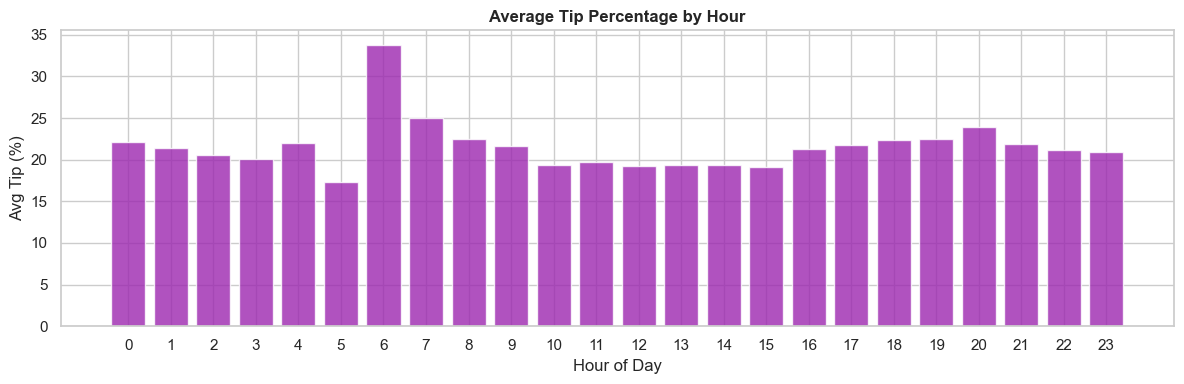

In [ ]:
# Cell 10 — PySpark distributed analysis
# Show off PySpark on full raw dataset

print("Running PySpark distributed analysis")
print("on full raw dataset...\n")

# Location popularity analysis
location_stats = df.groupBy(
    'PULocationID'
).agg(
    F.count('*').alias('total_pickups'),
    F.avg('fare_amount').alias('avg_fare'),
    F.avg('trip_distance').alias('avg_dist')
).orderBy(
    F.desc('total_pickups')
).limit(10)

print("=== TOP 10 PICKUP LOCATIONS ===")
location_stats.show()

# Payment type distribution
print("=== PAYMENT TYPE DISTRIBUTION ===")
payment_map = {
    '1': 'Credit Card',
    '2': 'Cash',
    '3': 'No Charge',
    '4': 'Dispute',
    '5': 'Unknown'
}

df.groupBy('payment_type') \
  .count() \
  .orderBy(F.desc('count')) \
  .show()

# Tip analysis by hour
print("=== TIP PERCENTAGE BY HOUR ===")
tip_by_hour = df.withColumn(
    'hour',
    F.hour('tpep_pickup_datetime')
).withColumn(
    'tip_pct',
    F.when(
        F.col('fare_amount') > 0,
        F.col('tip_amount') /
        F.col('fare_amount') * 100
    ).otherwise(0)
).groupBy('hour') \
 .agg(F.avg('tip_pct').alias('avg_tip_pct')) \
 .orderBy('hour')

tip_pdf = tip_by_hour.toPandas()

plt.figure(figsize=(12, 4))
plt.bar(tip_pdf['hour'],
        tip_pdf['avg_tip_pct'],
        color='#9C27B0', alpha=0.8)
plt.title('Average Tip Percentage by Hour',
          fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Avg Tip (%)')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig('../logs/tip_by_hour.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Cell 11 — Save aggregated data
import boto3
from sqlalchemy import create_engine

os.makedirs('../data/processed', exist_ok=True)

# Save locally as CSV
local_path = '../data/processed/hourly_stats.csv'
hourly_pdf.to_csv(local_path, index=False)
print(f"✅ Saved locally: {local_path}")

# Upload to S3
s3 = boto3.client(
    's3',
    aws_access_key_id=os.getenv(
        'AWS_ACCESS_KEY_ID'),
    aws_secret_access_key=os.getenv(
        'AWS_SECRET_ACCESS_KEY'),
    region_name=os.getenv('AWS_DEFAULT_REGION')
)
bucket = os.getenv('S3_BUCKET_DATA')

s3.upload_file(
    local_path, bucket,
    'project2/processed/hourly_stats.csv')
print(f"✅ Uploaded to S3")

# Store in RDS
conn_str = (
    f"postgresql://"
    f"{os.getenv('POSTGRES_USER')}:"
    f"{os.getenv('POSTGRES_PASSWORD')}@"
    f"{os.getenv('POSTGRES_HOST')}:"
    f"{os.getenv('POSTGRES_PORT')}/"
    f"{os.getenv('POSTGRES_DB')}"
)
engine = create_engine(conn_str)

rds_df = hourly_pdf[[
    'pickup_hour', 'trip_count',
    'avg_fare', 'avg_distance',
    'avg_passengers', 'total_revenue'
]].copy()

rds_df.to_sql(
    'hourly_trip_stats',
    engine,
    if_exists='replace',
    index=False,
    method='multi',
    chunksize=100
)
print(f"✅ Stored {len(rds_df):,} "
      f"rows in RDS")

✅ Saved locally: ../data/processed/hourly_stats.csv
✅ Uploaded to S3


AttributeError: 'Engine' object has no attribute 'cursor'

In [ ]:
#pip install sqlalchemy==2.0.36 greenlet==3.0.3

Note: you may need to restart the kernel to use updated packages.Collecting sqlalchemy==2.0.36
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 16.8 MB/s  0:00:00

  Attempting uninstall: greenlet

    Found existing installation: greenlet 1.1.3

    Uninstalling greenlet-1.1.3:

      Successfully uninstalled greenlet-1.1.3

   ---------------------------------------- 0/2 [greenlet]
   ---------------------------------------- 0/2 [greenlet]
   ---------------------------------------- 0/2 [greenlet]
   ---------------------------------------- 0/2 [greenlet]
   ---------------------------------------- 0/2 [greenlet]
   ---------------------------------------- 0/2 [greenlet]
   ---------------------------------------- 0/2 [greenlet]
   ---------------------------------------- 0/2 [greenlet]
   ---------------------------------------- 0/2 [greenlet]
   ---------------------------------------- 0/2 [greenlet]
   ----

  You can safely remove it manually.
  You can safely remove it manually.
